In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Meteorite_Landings.csv")
df.shape
df.head

<bound method NDFrame.head of              name     id nametype              recclass  mass (g)   fall  \
0          Aachen      1    Valid                    L5      21.0   Fell   
1          Aarhus      2    Valid                    H6     720.0   Fell   
2            Abee      6    Valid                   EH4  107000.0   Fell   
3        Acapulco     10    Valid           Acapulcoite    1914.0   Fell   
4         Achiras    370    Valid                    L6     780.0   Fell   
...           ...    ...      ...                   ...       ...    ...   
45711  Zillah 002  31356    Valid               Eucrite     172.0  Found   
45712      Zinder  30409    Valid  Pallasite, ungrouped      46.0  Found   
45713        Zlin  30410    Valid                    H4       3.3  Found   
45714   Zubkovsky  31357    Valid                    L6    2167.0  Found   
45715  Zulu Queen  30414    Valid                  L3.7     200.0  Found   

         year    reclat    reclong             GeoLocatio

In [3]:
df_filtered = df.dropna()

df_filtered = df_filtered[(df_filtered['year'] >= 1940) & (df_filtered['year'] <= 1980)]

print(df_filtered.shape)
print(df_filtered.head())

(5863, 10)
                   name   id nametype      recclass  mass (g)  fall    year  \
1                Aarhus    2    Valid            H6     720.0  Fell  1951.0   
2                  Abee    6    Valid           EH4  107000.0  Fell  1952.0   
3              Acapulco   10    Valid   Acapulcoite    1914.0  Fell  1976.0   
6   Adzhi-Bogdo (stone)  390    Valid         LL3-6     910.0  Fell  1949.0   
10     Aioun el Atrouss  423    Valid  Diogenite-pm    1000.0  Fell  1974.0   

      reclat    reclong           GeoLocation  
1   56.18333   10.23333  (56.18333, 10.23333)  
2   54.21667 -113.00000    (54.21667, -113.0)  
3   16.88333  -99.90000     (16.88333, -99.9)  
6   44.83333   95.16667  (44.83333, 95.16667)  
10  16.39806   -9.57028  (16.39806, -9.57028)  


In [21]:
import altair as alt
alt.data_transformers.enable('json')
import geopandas as gpd

# Load world map from Natural Earth
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Convert world map to Altair data
world_map = alt.Chart(world).mark_geoshape(
    fill='green', stroke='black'
).encode(
).project('mercator').properties(
    width=800,
    height=500
)

# Create an interactive scatter plot for meteorites
scatter = alt.Chart(df_filtered).mark_circle(size=50).encode(
    longitude='reclong:Q',
    latitude='reclat:Q',
    tooltip=['name:N', 'year:O', 'mass (g):Q', 'fall:N'],
    color=alt.Color('mass (g):Q', scale=alt.Scale(scheme='reds')),
    size=alt.Size('mass (g):Q', scale=alt.Scale(range=[10, 200]))
).interactive()

# Overlay both maps
final_map = world_map + scatter

# Display the final interactive map
final_map.properties(
    title="Meteorite Landings (1940-1980) Interactive Map"
)

/var/folders/gz/cq5r2gbd05z4qvs1bkf_y9r40000gn/T/ipykernel_9023/2377409590.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


alt.LayerChart(...)

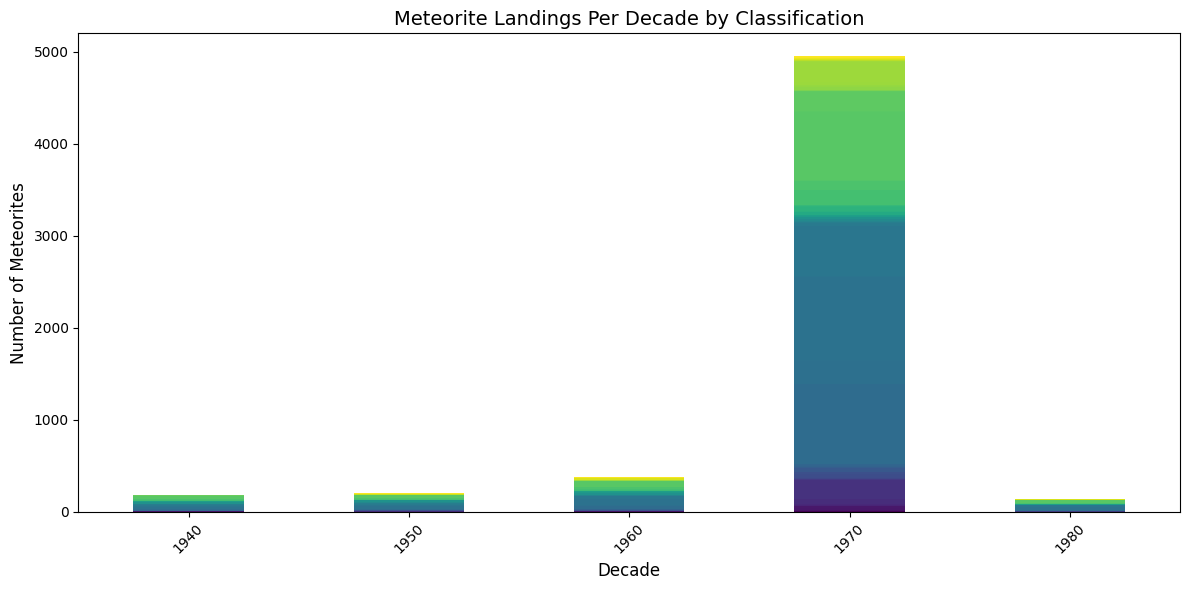

In [28]:
import matplotlib.pyplot as plt

# Extract decade
df_filtered['decade'] = (df_filtered['year'] // 10) * 10

# Count meteorites per decade and classification
meteorite_counts = df_filtered.groupby(['decade', 'recclass']).size().reset_index(name='count')

# Pivot for visualization
meteorite_pivot = meteorite_counts.pivot(index='decade', columns='recclass', values='count').fillna(0)

# Plot the bar graph without legend
fig, ax = plt.subplots(figsize=(12, 6))
meteorite_pivot.plot(kind='bar', stacked=True, colormap='viridis', ax=ax, legend=False)

# Set labels and title
ax.set_title("Meteorite Landings Per Decade by Classification", fontsize=14)
ax.set_xlabel("Decade", fontsize=12)
ax.set_ylabel("Number of Meteorites", fontsize=12)

# Adjust x-axis rotation
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()
